# Generate IRT Accuracy Plot

This notebook reads `experiments/history.jsonl`, computes best-so-far accuracy per run, averages across runs by trial number, and plots a single monotone curve.

In [1]:
from __future__ import annotations

import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt

HISTORY_PATH = Path("../experiments/history.jsonl")

if not HISTORY_PATH.exists():
    raise FileNotFoundError(f"Could not find history file at {HISTORY_PATH.resolve()}")

In [2]:
def load_history_records(path: Path) -> list[dict]:
    records: list[dict] = []

    for line_number, line in enumerate(path.read_text().splitlines(), start=1):
        stripped = line.strip()
        if not stripped:
            continue

        try:
            item = json.loads(stripped)
        except json.JSONDecodeError:
            print(f"Skipping malformed JSON at line {line_number}")
            continue

        if "trial_number" not in item or "score" not in item:
            print(f"Skipping line {line_number}: missing trial_number or score")
            continue

        records.append(item)

    return records


def split_runs(records: list[dict]) -> list[list[dict]]:
    if not records:
        return []

    runs: list[list[dict]] = []
    current_run: list[dict] = []
    previous_trial: int | None = None

    for record in records:
        trial_number = int(record["trial_number"])

        if previous_trial is not None and trial_number <= previous_trial and current_run:
            runs.append(current_run)
            current_run = []

        current_run.append(record)
        previous_trial = trial_number

    if current_run:
        runs.append(current_run)

    return runs


def best_so_far_by_trial(run: list[dict]) -> dict[int, float]:
    best_map: dict[int, float] = {}
    best_so_far = 0.0

    for record in run:
        trial_number = int(record["trial_number"])
        score = float(record["score"])
        best_so_far = max(best_so_far, score)
        best_map[trial_number] = best_so_far

    return best_map


records = load_history_records(HISTORY_PATH)
runs = split_runs(records)

if not runs:
    raise ValueError("No valid trial records found in history.jsonl")

per_run_best = [best_so_far_by_trial(run) for run in runs]

aggregate_by_trial: dict[int, list[float]] = defaultdict(list)
for run_best in per_run_best:
    for trial_number, best_value in run_best.items():
        aggregate_by_trial[trial_number].append(best_value)

x_values = sorted(aggregate_by_trial.keys())
y_avg_raw = [sum(aggregate_by_trial[x]) / len(aggregate_by_trial[x]) for x in x_values]

# Force monotone non-decreasing aggregate curve.
y_values: list[float] = []
running_best = 0.0
for value in y_avg_raw:
    running_best = max(running_best, value)
    y_values.append(running_best)

support_counts = [len(aggregate_by_trial[x]) for x in x_values]

print(f"Total records: {len(records)}")
print(f"Detected runs: {len(runs)}")
print(f"Trial range in aggregate: {x_values[0]} to {x_values[-1]}")

Total records: 42
Detected runs: 4
Trial range in aggregate: 1 to 24


In [3]:
print("x_values (trial_number):")
print(x_values)

print("\ny_values (average best-so-far accuracy, monotone):")
print(y_values)

print("\nsupport_counts (runs contributing at each trial_number):")
print(support_counts)

x_values (trial_number):
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]

y_values (average best-so-far accuracy, monotone):
[0.935, 0.9533333333333333, 0.9533333333333333, 0.98, 0.98, 0.99, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

support_counts (runs contributing at each trial_number):
[4, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1]


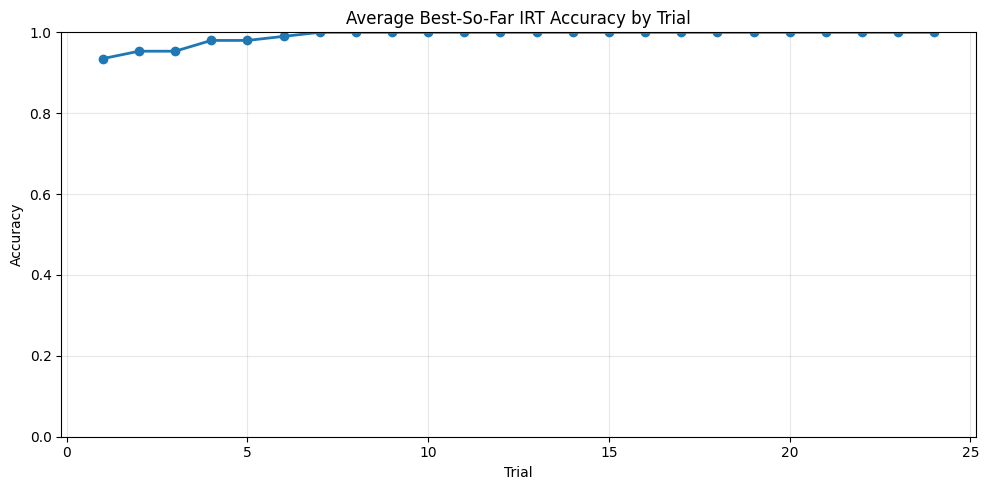

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(x_values, y_values, marker="o", linewidth=2)
plt.title("Average Best-So-Far IRT Accuracy by Trial")
plt.xlabel("Trial")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()